In [ ]:
!pip install iopath
!pip install webdataset
!pip install decord
!pip install bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=ecf0f5bd9790b2070b82a03e2b537c34616322f45e815a096fbc5aff1a337e9e
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built iopath
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.9 MB/s eta 0:00:00


# Mount the Drive for data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/CookiesAgent/MiniGPT-Pancreas2.0.git

Cloning into 'MiniGPT-Pancreas2.0'...
remote: Enumerating objects: 307, done.
remote: Counting objects: 100% (307/307), done.
remote: Compressing objects: 100% (241/241), done.
remote: Total 307 (delta 113), reused 196 (delta 45), pack-reused 0 (from 0)
Receiving objects: 100% (307/307), 174.01 KiB | 19.33 MiB/s, done.
Resolving deltas: 100% (113/113), done.


In [ ]:
!git lfs install


Git LFS initialized.


# Download Llama

In [ ]:
!hf auth login
from huggingface_hub import snapshot_download

# This will download the model to a local folder named 'llama-2-7b-chat-hf'
snapshot_download(
    repo_id="meta-llama/Llama-2-7b-chat-hf",
    local_dir="/content/Llama-2-7b-chat-hf",
    token=True # Uses the token you just logged in with
)


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? [y/N]: y
Token is valid (permission: read).
The token `PancreasGPT` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no helper is defined on your machine.
You might have to re-authenticate wh

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

'/content/Llama-2-7b-chat-hf'

In [ ]:
!pip install --upgrade gdown
import gdown

url = 'https://drive.google.com/uc?id=1HkoUUrjzFGn33cSiUkI-KcT-zysCynAz'
output = 'checkpoint_stage3.pth'
gdown.download(url, output, quiet=False)

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


Downloading...
From (original): https://drive.google.com/uc?id=1HkoUUrjzFGn33cSiUkI-KcT-zysCynAz
From (redirected): https://drive.google.com/uc?id=1HkoUUrjzFGn33cSiUkI-KcT-zysCynAz&confirm=t&uuid=6469de08-1d80-43cb-9a61-365ad23432fc
To: /content/checkpoint_stage3.pth
100%|██████████| 680M/680M [00:29<00:00, 22.7MB/s]


'checkpoint_stage3.pth'

# Datasets


## MSD

In [ ]:
import os
import shutil

# 1. Paths
tar_drive_path = '/content/drive/MyDrive/CSCI_597/Task07_Pancreas.tar'
tar_local_path = '/content/Task07_Pancreas.tar'
local_extract_path = '/content/temp_msd'
drive_target_path = '/content/MiniGPT-Pancreas2.0/datasets/MSD/raw_dataset'

# 2. Copy TAR to local SSD (much faster reading)
if not os.path.exists(tar_local_path):
    print("Copying TAR to local SSD... (est. 2-5 mins)")
    shutil.copy(tar_drive_path, tar_local_path)

# 3. Extract locally
os.makedirs(local_extract_path, exist_ok=True)
print("Extracting imagesTr and labelsTr locally...")
!tar -xf "{tar_local_path}" -C "{local_extract_path}" --strip-components=1 Task07_Pancreas/imagesTr Task07_Pancreas/labelsTr


Copying TAR to local SSD... (est. 2-5 mins)
Extracting imagesTr and labelsTr locally...


In [ ]:
# 4. Move to Google Drive
drive_target_path = '/content/MiniGPT-Pancreas2.0/datasets/MSD/raw_dataset'
drive_extract_path = '/content/drive/MyDrive/MiniGPT-Pancreas/datasets/MSD/raw_dataset'

print("Moving extracted folders to your Drive...")
os.makedirs(drive_target_path, exist_ok=True)

# Use !mv for speed
!mv {local_extract_path}/imagesTr {drive_target_path}/
!mv {drive_extract_path}/labelsTr {drive_target_path}/

print("Done! Check your Drive now.")

Moving extracted folders to your Drive...
mv: cannot stat '/content/drive/MyDrive/MiniGPT-Pancreas/datasets/MSD/raw_dataset/labelsTr': No such file or directory
Done! Check your Drive now.


### Preparing the Dataset

In [ ]:
!cp -r /content/drive/MyDrive/CSCI_597/MSD/raw_dataset/labelsTr/ /content/MiniGPT-Pancreas2.0/datasets/MSD/raw_dataset/labelsTr

In [ ]:
!mkdir -p /content/MiniGPT-Pancreas2.0/datasets/MSD/annotations
!cp /content/drive/MyDrive/CSCI_597/MSD/MSD*.json /content/MiniGPT-Pancreas2.0/datasets/MSD/annotations

In [ ]:
%cd /content/MiniGPT-Pancreas2.0/datasets/MSD/scripts

# 1. Extract info from 3D volumes
!python MSD_generate_slices_info.py

# 2. Generate JSON files (using --balanced as requested)
!python MSD_generate_jsons.py --balanced

# 3. Save slices as PNG (Warning: This will use massive disk space at 1000x1000)
!python MSD_save_slices.py --balanced

# 4. Tumor detection preparation
!python MSD_tumor_generate_jsons.py --balanced
!python MSD_tumor_save_slices.py --balanced

/content/MiniGPT-Pancreas2.0/datasets/MSD/scripts
Processing volumes: 100% 281/281 [03:40<00:00,  1.27it/s]
Data collection complete
Train JSON saved at: ../annotations/MSD_balanced_train.json | Pancreas: 2051, Non-pancreas: 2051
Test JSON saved at: ../annotations/MSD_balanced_test.json | Pancreas: 460, Non-pancreas: 460
MSD: 100% 5022/5022 [07:51<00:00, 10.65it/s]
MSD slices saved successfully in ../slices
Loaded 4102 train slices and 920 test slices
Train JSON saved at: ../annotations/MSD_tumor_balanced_train.json | Tumor: 1291, Non-tumor: 1291
Test JSON saved at: ../annotations/MSD_tumor_balanced_test.json | Tumor: 289, Non-tumor: 289
MSD: 100% 3160/3160 [05:13<00:00, 10.07it/s]
MSD slices saved successfully in ../slices
Loaded 2582 train slices and 578 test slices


# Assuming Dataset is ready

In [ ]:
import shutil
import os

# 1. Define the correct project path (Case Sensitive)
correct_tc_path = '/content/MiniGPT-Pancreas2.0/datasets'
zip_path = '/content/drive/MyDrive/CSCI_597/TC.zip'

# 2. Delete everything to start fresh
folders_to_delete = [
    '/content/minigpt-pancreas2.0',
    '/content/MiniGPT-Pancreas2.0/datasets/TC'
]

for folder in folders_to_delete:
    if os.path.exists(folder):
        print(f"Deleting old folder: {folder}")
        shutil.rmtree(folder)

# 3. Recreate the clean directory
os.makedirs(correct_tc_path, exist_ok=True)

# 4. Unzip directly into the correct path
print(f"Unzipping {zip_path}...")
!unzip -q "{zip_path}" -d "{correct_tc_path}"

# 5. Create the required annotations subfolder
os.makedirs(os.path.join(correct_tc_path, 'annotations'), exist_ok=True)

print("✅ TC folder recreated successfully.")

Deleting old folder: /content/MiniGPT-Pancreas2.0/datasets/TC
Unzipping /content/drive/MyDrive/CSCI_597/TC.zip...
✅ TC folder recreated successfully.


In [ ]:
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("meta-llama/Llama-2-7b-chat-hf")

print(tok("yes")["input_ids"])
print(tok("no")["input_ids"])

config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

[1, 4874]
[1, 694]


In [ ]:
import json
import numpy as np
from sklearn.model_selection import KFold
import os

# Paths
base_dir = '/content/MiniGPT-Pancreas2.0/datasets/TC/annotations'
source_json = os.path.join(base_dir, 'TC_train.json')

with open(source_json, 'r') as f:
    data = json.load(f)

# If data is a list of samples
samples = np.array(data)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(samples)):
    fold_dir = os.path.join(base_dir, f'fold_{fold}')
    os.makedirs(fold_dir, exist_ok=True)

    with open(os.path.join(fold_dir, 'train.json'), 'w') as f:
        json.dump(samples[train_idx].tolist(), f)
    with open(os.path.join(fold_dir, 'val.json'), 'w') as f:
        json.dump(samples[val_idx].tolist(), f)

print("5-Fold dataset splits created in annotations folder.")

5-Fold dataset splits created in annotations folder.


In [ ]:
%cd /content/MiniGPT-Pancreas2.0
!python train.py --cfg-path train_configs/minigptv2_finetune.yaml

/content/MiniGPT-Pancreas2.0
/usr/local/lib/python3.12/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
Not using distributed mode
2026-05-02 21:00:08,351 [INFO] Building datasets...
2026-05-02 21:00:08,368 [INFO] Using existing file /content/MiniGPT-Pancreas2.0/datasets/

# Evaluation

In [ ]:
import os
import shutil

# Define paths
drive_ckpt = '/content/drive/MyDrive/CSCI_597/checkpoints/20260501222/checkpoint_9.pth'
local_dir = '/content/MiniGPT-Pancreas2.0/output/minigptv2_finetune/20260501222/'
local_ckpt = os.path.join(local_dir, 'checkpoint_9.pth')

# Create local directory if it doesn't exist
os.makedirs(local_dir, exist_ok=True)

# Copy the file
if os.path.exists(drive_ckpt):
    print(f"Moving checkpoint to local content...")
    shutil.copy(drive_ckpt, local_ckpt)
    print(f" Success! Checkpoint is now at: {local_ckpt}")
else:
    print(f"Error: Could not find checkpoint at {drive_ckpt}")

Moving checkpoint to local content...
 Success! Checkpoint is now at: /content/MiniGPT-Pancreas2.0/output/minigptv2_finetune/20260501222/checkpoint_9.pth


In [ ]:
import sys
sys.path.append("/content/MiniGPT-Pancreas2.0")
import os
os.environ["PYTHONPATH"] = "/content/MiniGPT-Pancreas2.0"

In [ ]:
!pip install transformers==4.37.2
!pip install peft==0.7.1
!pip install accelerate==0.25.0

  Using cached transformers-4.37.2-py3-none-any.whl.metadata (129 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.37.2-py3-none-any.whl (8.4 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
Using cached tokenizers-0.15.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.13.0
    Uninstalling huggingface_hub-1.13.0:
      Successfully uninstalled huggingface_hub-1.13.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependen

In [ ]:
!pip uninstall bitsandbytes -y

Found existing installation: bitsandbytes 0.49.2
Uninstalling bitsandbytes-0.49.2:
  Successfully uninstalled bitsandbytes-0.49.2


In [ ]:
import os
os.kill(os.getpid(), 9)


When using the last checkpoint, we get the following:

\------------------------------

Matched Samples: 620

Actual Positives (Tumors): 310

Predicted Positives:       532

\------------------------------

Accuracy:  0.5548

Precision: 0.5320

Recall:    0.9129

F1 Score:  0.6722

\------------------------------

In [ ]:
%cd /content/MiniGPT-Pancreas2.0/eval_scripts

!PYTHONPATH=$PYTHONPATH:/content/MiniGPT-Pancreas \
torchrun --master-port 29501 --nproc_per_node 1 eval_vqa.py \
    --cfg-path ../eval_configs/minigptv2_benchmark_evaluation.yaml

/content/MiniGPT-Pancreas2.0/eval_scripts
/usr/local/lib/python3.12/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
Initialization Model
Loading checkpoint shards: 100% 2/2 [00:02<00:00,  1.14s/it]
trainable params: 33,554,432 || all params: 6,771,970,048 || trainable%: 

In [ ]:
ls -l /content/MiniGPT-Pancreas2.0/eval_results/TC_predictions.json

-rw-r--r-- 1 root root 25518 May  3 05:15 /content/MiniGPT-Pancreas2.0/eval_results/TC_predictions.json


In [ ]:
import json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Paths
pred_path = '/content/MiniGPT-Pancreas2.0/eval_results/TC_predictions.json'
gt_path = '/content/MiniGPT-Pancreas2.0/datasets/TC/annotations/TC_test.json'

# Load files
with open(pred_path, 'r') as f:
    preds = json.load(f)
with open(gt_path, 'r') as f:
    gts = json.load(f)

# Create ground truth lookup: map q_id to binary (1 for yes, 0 for no)
gt_lookup = {item['q_id']: (1 if item['answer'].lower() == 'yes' else 0) for item in gts}

y_true = []
y_pred = []

for p in preds:
    # Use question_id from prediction to find q_id in ground truth
    qid = p.get('question_id')
    if qid in gt_lookup:
        y_true.append(gt_lookup[qid])
        y_pred.append(1 if p['answer'].lower() == 'yes' else 0)

# Final calculation
if not y_true:
    print("Error: Could not match question_id to q_id. Check key names.")
else:
    print("-" * 30)
    print(f"Matched Samples: {len(y_true)}")
    print(f"Actual Positives (Tumors): {sum(y_true)}")
    print(f"Predicted Positives:       {sum(y_pred)}")
    print("-" * 30)
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print("-" * 30)

------------------------------
Matched Samples: 620
Actual Positives (Tumors): 310
Predicted Positives:       497
------------------------------
Accuracy:  0.5726
Precision: 0.5453
Recall:    0.8742
F1 Score:  0.6716
------------------------------


In [ ]:
!torchrun --master-port 29501 --nproc_per_node 1 eval_ref.py --cfg-path ../eval_configs/minigptv2_benchmark_evaluation.yaml --tasks tumor_detection

/usr/local/lib/python3.12/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
Initialization Model
Loading checkpoint shards: 100% 2/2 [00:04<00:00,  2.27s/it]
trainable params: 33,554,432 || all params: 6,771,970,048 || trainable%: 0.49548996469513035
Position interpolate f

In [ ]:
file_path = "/content/drive/MyDrive/CSCI_597/logs/02052026_061951.log"

try:
    with open(file_path, "r", encoding="utf-8") as f:
        content = f.read()
        print(content)
except FileNotFoundError:
    print(f"File not found: {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")



=== [02052026_061951] Task: tumor_detection ===
--- Evaluation for task: tumor_detection ---
Checkpoint: /content/MiniGPT-Pancreas2.0/output/minigptv2_finetune/20260501222/checkpoint_14.pth

Dataset: MSD
  Samples: 310
  Detection Accuracy: 55.50%
  Average IoU: 0.312
  Average DSC: 0.476
  Bad answers: 2
  Invalid predictions: 0
  Missing predictions: 2

--- Weighted (combined) metrics ---
  Total samples: 310
  Weighted Detection Accuracy: 55.50%
  Weighted Average IoU: 0.312
  Weighted Average DSC: 0.476




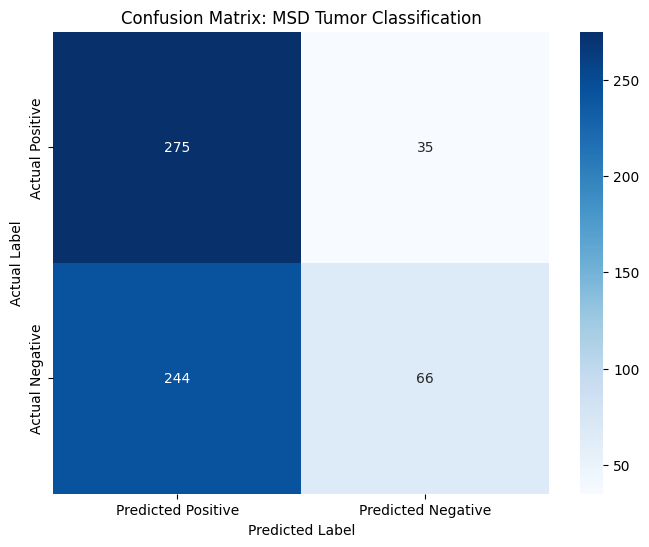

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data from reconstruction
cm = np.array([[275, 35],
               [244, 66]])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'])

plt.title('Confusion Matrix: MSD Tumor Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

I wish I had time to fix this...

In [ ]:
import shutil
import os

# Create local directory
os.makedirs('/content/MSD_data/', exist_ok=True)

# List of files to move
files = [
    'MSD_test.json',
    'MSD_balanced_test.json',
    'MSD_tumor_balanced_test.json'
]

for f in files:
    src = f'/content/drive/MyDrive/CSCI_597/MSD/{f}'
    dst = f'/content/MSD_data/{f}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Moved: {f}")
    else:
        print(f"Error: {src} not found.")

Moved: MSD_test.json
Moved: MSD_balanced_test.json
Moved: MSD_tumor_balanced_test.json


In [ ]:
import json
with open('/content/drive/MyDrive/CSCI_597/MSD/MSD_tumor_balanced_test.json', 'r') as f:
    data = json.load(f)
    # Print the first 3 entries to see the keys and values
    print(json.dumps(data[:3], indent=2))

[
  {
    "dataset": "MSD",
    "volume_name": "pancreas_069.nii.gz",
    "slice_id": 3337,
    "slice_index": 58,
    "slice_count": 97,
    "pixels_pancreas": 2792,
    "pancreas_pixels_ratio": 0.61,
    "max_pixels_pancreas": 4581,
    "pixels_tumor": 945,
    "tumor_pixels_ratio": 0.5,
    "max_pixels_tumor": 1902,
    "bbox_pancreas": [
      195,
      195,
      262,
      253
    ],
    "pancreas_bbox_ratio": 0.4,
    "max_bbox_pancreas": 9828,
    "bbox_tumor": [
      201,
      207,
      243,
      243
    ],
    "tumor_bbox_ratio": 0.65,
    "max_bbox_tumor": 2332,
    "width": 512,
    "height": 512,
    "q_id": 1
  },
  {
    "dataset": "MSD",
    "volume_name": "pancreas_069.nii.gz",
    "slice_id": 3338,
    "slice_index": 59,
    "slice_count": 97,
    "pixels_pancreas": 3127,
    "pancreas_pixels_ratio": 0.68,
    "max_pixels_pancreas": 4581,
    "pixels_tumor": 1734,
    "tumor_pixels_ratio": 0.91,
    "max_pixels_tumor": 1902,
    "bbox_pancreas": [
      191,
    

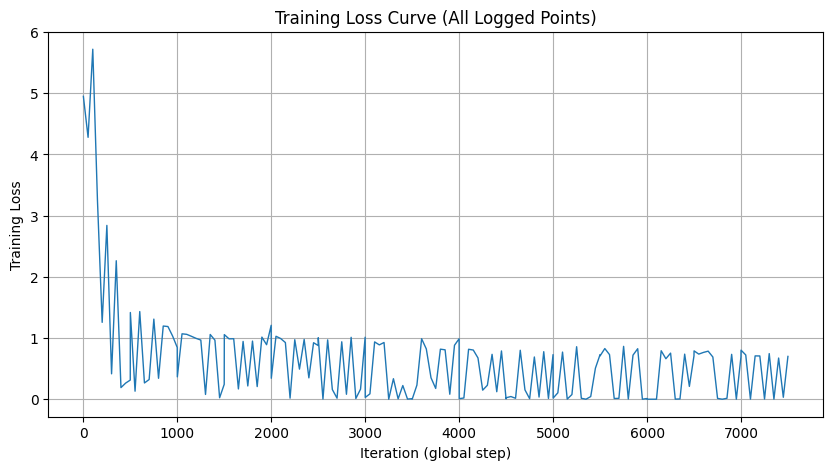

In [3]:
import re
import matplotlib.pyplot as plt

log_text = """/content/MiniGPT-Pancreas2.0
/usr/local/lib/python3.12/dist-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
Not using distributed mode
2026-05-02 21:00:08,351 [INFO] Building datasets...
2026-05-02 21:00:08,368 [INFO] Using existing file /content/MiniGPT-Pancreas2.0/datasets/TC/annotations/TC_train.json.
2026-05-02 21:00:08,368 [INFO] Building datasets...
vis_root: /content/MiniGPT-Pancreas2.0/datasets/TC/slices
Final dataset size after oversampling: 5080
2026-05-02 21:00:08,421 [INFO] Loading LLAMA
Loading weights: 100% 291/291 [00:15<00:00, 18.55it/s, Materializing param=model.norm.weight]
trainable params: 33,554,432 || all params: 6,771,970,048 || trainable%: 0.4955
2026-05-02 21:00:28,203 [INFO] Loading LLAMA Done
2026-05-02 21:00:28,203 [INFO] Loading VIT
Position interpolate from 16x16 to 32x32
2026-05-02 21:00:42,450 [INFO] freeze vision encoder
2026-05-02 21:00:42,450 [INFO] Loading VIT Done
Load Minigpt-4-LLM Checkpoint: /content/checkpoint_stage3.pth
2026-05-02 21:00:43,117 [INFO] Start training
2026-05-02 21:00:43,624 [INFO] dataset_ratios not specified, datasets will be concatenated (map-style datasets) or chained (webdataset.DataPipeline).
2026-05-02 21:00:43,624 [INFO] Loaded 3810 records for train split from the dataset.
2026-05-02 21:00:43,644 [INFO] number of trainable parameters: 56627200
/content/MiniGPT-Pancreas2.0/minigpt4/runners/runner_base.py:136: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self._scaler = torch.cuda.amp.GradScaler()
2026-05-02 21:00:43,645 [INFO] Start training epoch 0, 500 iters per inner epoch.
/content/MiniGPT-Pancreas2.0/minigpt4/tasks/base_task.py:219: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/content/MiniGPT-Pancreas2.0/minigpt4/models/base_model.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
Train: data epoch: [0]  [  0/500]  eta: 0:40:21  lr: 0.000001  loss: 4.9481  time: 4.8428  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [ 50/500]  eta: 0:24:36  lr: 0.000001  loss: 4.2787  time: 3.2460  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [100/500]  eta: 0:21:44  lr: 0.000002  loss: 5.7183  time: 3.2397  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [150/500]  eta: 0:18:58  lr: 0.000002  loss: 3.2428  time: 3.2403  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [200/500]  eta: 0:16:14  lr: 0.000003  loss: 1.2559  time: 3.2368  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [250/500]  eta: 0:13:31  lr: 0.000003  loss: 2.8400  time: 3.2369  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [300/500]  eta: 0:10:49  lr: 0.000004  loss: 0.4152  time: 3.2409  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [350/500]  eta: 0:08:06  lr: 0.000004  loss: 2.2627  time: 3.2405  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [400/500]  eta: 0:05:24  lr: 0.000005  loss: 0.1901  time: 3.2608  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [450/500]  eta: 0:02:42  lr: 0.000005  loss: 0.2638  time: 3.2375  data: 0.0000  max mem: 12407
Train: data epoch: [0]  [499/500]  eta: 0:00:03  lr: 0.000005  loss: 0.3130  time: 3.2365  data: 0.0000  max mem: 12407
Train: data epoch: [0] Total time: 0:27:01 (3.2431 s / it)
2026-05-02 21:27:45,219 [INFO] Averaged stats: lr: 0.0000  loss: 2.8860
2026-05-02 21:27:45,224 [INFO] No validation splits found.
2026-05-02 21:27:45,255 [INFO] Saving checkpoint at epoch 0 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_0.pth.
2026-05-02 21:27:47,026 [INFO] Start training
2026-05-02 21:27:47,061 [INFO] Start training epoch 1, 500 iters per inner epoch.
Train: data epoch: [1]  [  0/500]  eta: 0:26:45  lr: 0.000001  loss: 1.4169  time: 3.2111  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [ 50/500]  eta: 0:24:16  lr: 0.000001  loss: 0.1312  time: 3.2379  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [100/500]  eta: 0:21:34  lr: 0.000002  loss: 1.4324  time: 3.2345  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [150/500]  eta: 0:18:58  lr: 0.000002  loss: 0.2658  time: 3.3625  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [200/500]  eta: 0:16:14  lr: 0.000003  loss: 0.3222  time: 3.2336  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [250/500]  eta: 0:13:31  lr: 0.000003  loss: 1.3090  time: 3.2374  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [300/500]  eta: 0:10:48  lr: 0.000004  loss: 0.3421  time: 3.2370  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [350/500]  eta: 0:08:06  lr: 0.000004  loss: 1.1957  time: 3.2358  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [400/500]  eta: 0:05:24  lr: 0.000005  loss: 1.1877  time: 3.2343  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [450/500]  eta: 0:02:42  lr: 0.000005  loss: 1.0313  time: 3.2378  data: 0.0000  max mem: 12407
Train: data epoch: [1]  [499/500]  eta: 0:00:03  lr: 0.000005  loss: 0.8453  time: 3.2329  data: 0.0000  max mem: 12407
Train: data epoch: [1] Total time: 0:27:00 (3.2406 s / it)
2026-05-02 21:54:47,347 [INFO] Averaged stats: lr: 0.0000  loss: 0.7866
2026-05-02 21:54:47,352 [INFO] No validation splits found.
2026-05-02 21:54:47,385 [INFO] Saving checkpoint at epoch 1 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_1.pth.
2026-05-02 21:54:48,843 [INFO] Start training
2026-05-02 21:54:48,877 [INFO] Start training epoch 2, 500 iters per inner epoch.
Train: data epoch: [2]  [  0/500]  eta: 0:26:44  lr: 0.000010  loss: 0.3652  time: 3.2095  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [ 50/500]  eta: 0:24:16  lr: 0.000010  loss: 1.0687  time: 3.2365  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [100/500]  eta: 0:21:34  lr: 0.000010  loss: 1.0600  time: 3.2364  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [150/500]  eta: 0:18:52  lr: 0.000009  loss: 1.0281  time: 3.2351  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [200/500]  eta: 0:16:10  lr: 0.000009  loss: 0.9942  time: 3.2325  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [250/500]  eta: 0:13:31  lr: 0.000009  loss: 0.9666  time: 3.2363  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [300/500]  eta: 0:10:48  lr: 0.000009  loss: 0.0782  time: 3.2341  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [350/500]  eta: 0:08:06  lr: 0.000009  loss: 1.0577  time: 3.2314  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [400/500]  eta: 0:05:24  lr: 0.000009  loss: 0.9654  time: 3.2389  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [450/500]  eta: 0:02:42  lr: 0.000009  loss: 0.0238  time: 3.2349  data: 0.0000  max mem: 12407
Train: data epoch: [2]  [499/500]  eta: 0:00:03  lr: 0.000009  loss: 0.2429  time: 3.2361  data: 0.0000  max mem: 12407
Train: data epoch: [2] Total time: 0:27:02 (3.2459 s / it)
2026-05-02 22:21:51,834 [INFO] Averaged stats: lr: 0.0000  loss: 0.6619
2026-05-02 22:21:51,838 [INFO] No validation splits found.
2026-05-02 22:21:51,872 [INFO] Saving checkpoint at epoch 2 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_2.pth.
2026-05-02 22:21:53,310 [INFO] Start training
2026-05-02 22:21:53,345 [INFO] Start training epoch 3, 500 iters per inner epoch.
Train: data epoch: [3]  [  0/500]  eta: 0:26:49  lr: 0.000009  loss: 1.0557  time: 3.2191  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [ 50/500]  eta: 0:24:15  lr: 0.000009  loss: 0.9867  time: 3.2344  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [100/500]  eta: 0:21:34  lr: 0.000009  loss: 0.9882  time: 3.2363  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [150/500]  eta: 0:18:52  lr: 0.000009  loss: 0.1681  time: 3.2346  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [200/500]  eta: 0:16:10  lr: 0.000009  loss: 0.9442  time: 3.2347  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [250/500]  eta: 0:13:28  lr: 0.000009  loss: 0.2169  time: 3.2354  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [300/500]  eta: 0:10:48  lr: 0.000009  loss: 0.9500  time: 3.3575  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [350/500]  eta: 0:08:06  lr: 0.000009  loss: 0.2067  time: 3.2317  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [400/500]  eta: 0:05:24  lr: 0.000009  loss: 1.0150  time: 3.2316  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [450/500]  eta: 0:02:41  lr: 0.000009  loss: 0.8908  time: 3.2276  data: 0.0000  max mem: 12407
Train: data epoch: [3]  [499/500]  eta: 0:00:03  lr: 0.000009  loss: 1.2080  time: 3.2337  data: 0.0000  max mem: 12407
Train: data epoch: [3] Total time: 0:26:59 (3.2386 s / it)
2026-05-02 22:48:52,650 [INFO] Averaged stats: lr: 0.0000  loss: 0.6192
2026-05-02 22:48:52,655 [INFO] No validation splits found.
2026-05-02 22:48:52,688 [INFO] Saving checkpoint at epoch 3 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_3.pth.
2026-05-02 22:48:54,099 [INFO] Start training
2026-05-02 22:48:54,133 [INFO] Start training epoch 4, 500 iters per inner epoch.
Train: data epoch: [4]  [  0/500]  eta: 0:26:41  lr: 0.000009  loss: 0.3423  time: 3.2025  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [ 50/500]  eta: 0:24:18  lr: 0.000008  loss: 1.0287  time: 3.2300  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [100/500]  eta: 0:21:33  lr: 0.000008  loss: 0.9913  time: 3.2295  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [150/500]  eta: 0:18:52  lr: 0.000008  loss: 0.9262  time: 3.2329  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [200/500]  eta: 0:16:10  lr: 0.000008  loss: 0.0173  time: 3.2311  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [250/500]  eta: 0:13:28  lr: 0.000008  loss: 0.9727  time: 3.2373  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [300/500]  eta: 0:10:46  lr: 0.000008  loss: 0.4921  time: 3.2297  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [350/500]  eta: 0:08:05  lr: 0.000008  loss: 0.9770  time: 3.2367  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [400/500]  eta: 0:05:23  lr: 0.000008  loss: 0.3491  time: 3.2360  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [450/500]  eta: 0:02:41  lr: 0.000008  loss: 0.9231  time: 3.2323  data: 0.0000  max mem: 12407
Train: data epoch: [4]  [499/500]  eta: 0:00:03  lr: 0.000008  loss: 0.8778  time: 3.2341  data: 0.0000  max mem: 12407
Train: data epoch: [4] Total time: 0:26:59 (3.2385 s / it)
2026-05-02 23:15:53,403 [INFO] Averaged stats: lr: 0.0000  loss: 0.5636
2026-05-02 23:15:53,409 [INFO] No validation splits found.
2026-05-02 23:15:53,442 [INFO] Saving checkpoint at epoch 4 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_4.pth.
2026-05-02 23:15:55,459 [INFO] Start training
2026-05-02 23:15:55,493 [INFO] Start training epoch 5, 500 iters per inner epoch.
Train: data epoch: [5]  [  0/500]  eta: 0:26:53  lr: 0.000008  loss: 1.0043  time: 3.2279  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [ 50/500]  eta: 0:24:15  lr: 0.000008  loss: 0.0028  time: 3.2340  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [100/500]  eta: 0:21:33  lr: 0.000008  loss: 0.9699  time: 3.2328  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [150/500]  eta: 0:18:51  lr: 0.000008  loss: 0.1581  time: 3.2318  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [200/500]  eta: 0:16:13  lr: 0.000007  loss: 0.0168  time: 3.3575  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [250/500]  eta: 0:13:30  lr: 0.000007  loss: 0.9383  time: 3.2303  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [300/500]  eta: 0:10:48  lr: 0.000007  loss: 0.0809  time: 3.2337  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [350/500]  eta: 0:08:06  lr: 0.000007  loss: 1.0116  time: 3.2539  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [400/500]  eta: 0:05:23  lr: 0.000007  loss: 0.0113  time: 3.2319  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [450/500]  eta: 0:02:41  lr: 0.000007  loss: 0.1650  time: 3.2348  data: 0.0000  max mem: 12407
Train: data epoch: [5]  [499/500]  eta: 0:00:03  lr: 0.000007  loss: 1.0132  time: 3.2321  data: 0.0000  max mem: 12407
Train: data epoch: [5] Total time: 0:26:58 (3.2377 s / it)
2026-05-02 23:42:54,329 [INFO] Averaged stats: lr: 0.0000  loss: 0.5247
2026-05-02 23:42:54,334 [INFO] No validation splits found.
2026-05-02 23:42:54,364 [INFO] Saving checkpoint at epoch 5 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_5.pth.
2026-05-02 23:42:55,735 [INFO] Start training
2026-05-02 23:42:55,773 [INFO] Start training epoch 6, 500 iters per inner epoch.
Train: data epoch: [6]  [  0/500]  eta: 0:26:42  lr: 0.000007  loss: 0.0295  time: 3.2059  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [ 50/500]  eta: 0:24:36  lr: 0.000007  loss: 0.0878  time: 3.3573  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [100/500]  eta: 0:21:42  lr: 0.000007  loss: 0.9365  time: 3.2286  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [150/500]  eta: 0:18:57  lr: 0.000007  loss: 0.8879  time: 3.2358  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [200/500]  eta: 0:16:13  lr: 0.000007  loss: 0.9270  time: 3.2324  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [250/500]  eta: 0:13:30  lr: 0.000006  loss: 0.0002  time: 3.2317  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [300/500]  eta: 0:10:47  lr: 0.000006  loss: 0.3352  time: 3.2303  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [350/500]  eta: 0:08:05  lr: 0.000006  loss: 0.0058  time: 3.2271  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [400/500]  eta: 0:05:23  lr: 0.000006  loss: 0.2238  time: 3.2308  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [450/500]  eta: 0:02:41  lr: 0.000006  loss: 0.0026  time: 3.2332  data: 0.0000  max mem: 12407
Train: data epoch: [6]  [499/500]  eta: 0:00:03  lr: 0.000006  loss: 0.0090  time: 3.2324  data: 0.0000  max mem: 12407
Train: data epoch: [6] Total time: 0:26:57 (3.2358 s / it)
2026-05-03 00:09:53,658 [INFO] Averaged stats: lr: 0.0000  loss: 0.4958
2026-05-03 00:09:53,662 [INFO] No validation splits found.
2026-05-03 00:09:53,697 [INFO] Saving checkpoint at epoch 6 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_6.pth.
2026-05-03 00:09:55,150 [INFO] Start training
2026-05-03 00:09:55,188 [INFO] Start training epoch 7, 500 iters per inner epoch.
Train: data epoch: [7]  [  0/500]  eta: 0:26:43  lr: 0.000006  loss: 0.0014  time: 3.2078  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [ 50/500]  eta: 0:24:17  lr: 0.000006  loss: 0.2305  time: 3.2377  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [100/500]  eta: 0:21:34  lr: 0.000006  loss: 0.9883  time: 3.2346  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [150/500]  eta: 0:18:53  lr: 0.000006  loss: 0.8219  time: 3.2566  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [200/500]  eta: 0:16:15  lr: 0.000006  loss: 0.3507  time: 3.3648  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [250/500]  eta: 0:13:31  lr: 0.000005  loss: 0.1764  time: 3.2362  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [300/500]  eta: 0:10:49  lr: 0.000005  loss: 0.8179  time: 3.2408  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [350/500]  eta: 0:08:06  lr: 0.000005  loss: 0.8073  time: 3.2375  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [400/500]  eta: 0:05:24  lr: 0.000005  loss: 0.0815  time: 3.2361  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [450/500]  eta: 0:02:42  lr: 0.000005  loss: 0.8815  time: 3.2319  data: 0.0000  max mem: 12407
Train: data epoch: [7]  [499/500]  eta: 0:00:03  lr: 0.000005  loss: 0.9871  time: 3.2349  data: 0.0000  max mem: 12407
Train: data epoch: [7] Total time: 0:27:03 (3.2462 s / it)
2026-05-03 00:36:58,283 [INFO] Averaged stats: lr: 0.0000  loss: 0.4856
2026-05-03 00:36:58,288 [INFO] No validation splits found.
2026-05-03 00:36:58,322 [INFO] Saving checkpoint at epoch 7 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_7.pth.
2026-05-03 00:37:00,279 [INFO] Start training
2026-05-03 00:37:00,315 [INFO] Start training epoch 8, 500 iters per inner epoch.
Train: data epoch: [8]  [  0/500]  eta: 0:26:40  lr: 0.000005  loss: 0.0090  time: 3.2011  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [ 50/500]  eta: 0:24:15  lr: 0.000005  loss: 0.0202  time: 3.2321  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [100/500]  eta: 0:21:33  lr: 0.000005  loss: 0.8163  time: 3.2325  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [150/500]  eta: 0:18:51  lr: 0.000005  loss: 0.8037  time: 3.2361  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [200/500]  eta: 0:16:10  lr: 0.000005  loss: 0.6744  time: 3.2321  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [250/500]  eta: 0:13:28  lr: 0.000005  loss: 0.1479  time: 3.2345  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [300/500]  eta: 0:10:46  lr: 0.000004  loss: 0.2280  time: 3.2352  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [350/500]  eta: 0:08:06  lr: 0.000004  loss: 0.7336  time: 3.2348  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [400/500]  eta: 0:05:24  lr: 0.000004  loss: 0.1226  time: 3.2370  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [450/500]  eta: 0:02:42  lr: 0.000004  loss: 0.7887  time: 3.2571  data: 0.0000  max mem: 12407
Train: data epoch: [8]  [499/500]  eta: 0:00:03  lr: 0.000004  loss: 0.0055  time: 3.2323  data: 0.0000  max mem: 12407
Train: data epoch: [8] Total time: 0:27:00 (3.2403 s / it)
2026-05-03 01:04:00,450 [INFO] Averaged stats: lr: 0.0000  loss: 0.4295
2026-05-03 01:04:00,455 [INFO] No validation splits found.
2026-05-03 01:04:00,495 [INFO] Saving checkpoint at epoch 8 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_8.pth.
2026-05-03 01:04:01,934 [INFO] Start training
2026-05-03 01:04:01,972 [INFO] Start training epoch 9, 500 iters per inner epoch.
Train: data epoch: [9]  [  0/500]  eta: 0:26:41  lr: 0.000004  loss: 0.0241  time: 3.2035  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [ 50/500]  eta: 0:24:16  lr: 0.000004  loss: 0.0439  time: 3.2377  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [100/500]  eta: 0:21:34  lr: 0.000004  loss: 0.0157  time: 3.2361  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [150/500]  eta: 0:18:52  lr: 0.000004  loss: 0.7999  time: 3.2344  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [200/500]  eta: 0:16:10  lr: 0.000004  loss: 0.1531  time: 3.2331  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [250/500]  eta: 0:13:28  lr: 0.000004  loss: 0.0083  time: 3.2350  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [300/500]  eta: 0:10:47  lr: 0.000004  loss: 0.6901  time: 3.2404  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [350/500]  eta: 0:08:05  lr: 0.000003  loss: 0.0353  time: 3.2325  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [400/500]  eta: 0:05:23  lr: 0.000003  loss: 0.7768  time: 3.2291  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [450/500]  eta: 0:02:41  lr: 0.000003  loss: 0.0131  time: 3.2328  data: 0.0000  max mem: 12407
Train: data epoch: [9]  [499/500]  eta: 0:00:03  lr: 0.000003  loss: 0.7289  time: 3.3547  data: 0.0000  max mem: 12407
Train: data epoch: [9] Total time: 0:26:59 (3.2390 s / it)
2026-05-03 01:31:01,497 [INFO] Averaged stats: lr: 0.0000  loss: 0.4160
2026-05-03 01:31:01,503 [INFO] No validation splits found.
2026-05-03 01:31:01,540 [INFO] Saving checkpoint at epoch 9 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_9.pth.
2026-05-03 01:31:03,030 [INFO] Start training
2026-05-03 01:31:03,064 [INFO] Start training epoch 10, 500 iters per inner epoch.
Train: data epoch: [10]  [  0/500]  eta: 0:26:42  lr: 0.000003  loss: 0.0186  time: 3.2040  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [ 50/500]  eta: 0:24:14  lr: 0.000003  loss: 0.1047  time: 3.2309  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [100/500]  eta: 0:21:33  lr: 0.000003  loss: 0.7703  time: 3.2335  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [150/500]  eta: 0:18:51  lr: 0.000003  loss: 0.0022  time: 3.2366  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [200/500]  eta: 0:16:13  lr: 0.000003  loss: 0.0766  time: 3.2336  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [250/500]  eta: 0:13:31  lr: 0.000003  loss: 0.8580  time: 3.2521  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [300/500]  eta: 0:10:48  lr: 0.000003  loss: 0.0153  time: 3.2319  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [350/500]  eta: 0:08:06  lr: 0.000003  loss: 0.0003  time: 3.2354  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [400/500]  eta: 0:05:24  lr: 0.000003  loss: 0.0438  time: 3.2370  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [450/500]  eta: 0:02:42  lr: 0.000003  loss: 0.5075  time: 3.2348  data: 0.0000  max mem: 12407
Train: data epoch: [10]  [499/500]  eta: 0:00:03  lr: 0.000002  loss: 0.7273  time: 3.2322  data: 0.0000  max mem: 12407
Train: data epoch: [10] Total time: 0:27:00 (3.2402 s / it)
2026-05-03 01:58:03,168 [INFO] Averaged stats: lr: 0.0000  loss: 0.4055
2026-05-03 01:58:03,173 [INFO] No validation splits found.
2026-05-03 01:58:03,206 [INFO] Saving checkpoint at epoch 10 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_10.pth.
2026-05-03 01:58:05,125 [INFO] Start training
2026-05-03 01:58:05,161 [INFO] Start training epoch 11, 500 iters per inner epoch.
Train: data epoch: [11]  [  0/500]  eta: 0:26:57  lr: 0.000002  loss: 0.7090  time: 3.2351  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [ 50/500]  eta: 0:24:15  lr: 0.000002  loss: 0.8279  time: 3.2301  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [100/500]  eta: 0:21:34  lr: 0.000002  loss: 0.7293  time: 3.2382  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [150/500]  eta: 0:18:58  lr: 0.000002  loss: 0.0118  time: 3.2396  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [200/500]  eta: 0:16:14  lr: 0.000002  loss: 0.0142  time: 3.2364  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [250/500]  eta: 0:13:31  lr: 0.000002  loss: 0.8637  time: 3.2334  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [300/500]  eta: 0:10:48  lr: 0.000002  loss: 0.0034  time: 3.2399  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [350/500]  eta: 0:08:06  lr: 0.000002  loss: 0.7202  time: 3.2323  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [400/500]  eta: 0:05:24  lr: 0.000002  loss: 0.8254  time: 3.2336  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [450/500]  eta: 0:02:42  lr: 0.000002  loss: 0.0005  time: 3.2339  data: 0.0000  max mem: 12407
Train: data epoch: [11]  [499/500]  eta: 0:00:03  lr: 0.000002  loss: 0.0116  time: 3.2329  data: 0.0000  max mem: 12407
Train: data epoch: [11] Total time: 0:26:59 (3.2393 s / it)
2026-05-03 02:25:04,825 [INFO] Averaged stats: lr: 0.0000  loss: 0.4210
2026-05-03 02:25:04,830 [INFO] No validation splits found.
2026-05-03 02:25:04,864 [INFO] Saving checkpoint at epoch 11 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_11.pth.
2026-05-03 02:25:06,817 [INFO] Start training
2026-05-03 02:25:06,852 [INFO] Start training epoch 12, 500 iters per inner epoch.
Train: data epoch: [12]  [  0/500]  eta: 0:26:36  lr: 0.000002  loss: 0.0002  time: 3.1939  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [ 50/500]  eta: 0:24:14  lr: 0.000002  loss: 0.0009  time: 3.2316  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [100/500]  eta: 0:21:34  lr: 0.000002  loss: 0.0002  time: 3.2353  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [150/500]  eta: 0:18:52  lr: 0.000002  loss: 0.7921  time: 3.2349  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [200/500]  eta: 0:16:10  lr: 0.000002  loss: 0.6617  time: 3.2427  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [250/500]  eta: 0:13:29  lr: 0.000002  loss: 0.7532  time: 3.2358  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [300/500]  eta: 0:10:48  lr: 0.000002  loss: 0.0018  time: 3.2371  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [350/500]  eta: 0:08:06  lr: 0.000002  loss: 0.0044  time: 3.2359  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [400/500]  eta: 0:05:24  lr: 0.000001  loss: 0.7367  time: 3.2302  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [450/500]  eta: 0:02:42  lr: 0.000001  loss: 0.2094  time: 3.2341  data: 0.0000  max mem: 12407
Train: data epoch: [12]  [499/500]  eta: 0:00:03  lr: 0.000001  loss: 0.7076  time: 3.2312  data: 0.0000  max mem: 12407
Train: data epoch: [12] Total time: 0:27:03 (3.2463 s / it)
2026-05-03 02:52:09,982 [INFO] Averaged stats: lr: 0.0000  loss: 0.4143
2026-05-03 02:52:09,987 [INFO] No validation splits found.
2026-05-03 02:52:10,021 [INFO] Saving checkpoint at epoch 12 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_12.pth.
2026-05-03 02:52:11,571 [INFO] Start training
2026-05-03 02:52:11,608 [INFO] Start training epoch 13, 500 iters per inner epoch.
Train: data epoch: [13]  [  0/500]  eta: 0:26:52  lr: 0.000001  loss: 0.7901  time: 3.2254  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [ 50/500]  eta: 0:24:15  lr: 0.000001  loss: 0.7372  time: 3.2327  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [100/500]  eta: 0:21:33  lr: 0.000001  loss: 0.7648  time: 3.2291  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [150/500]  eta: 0:18:52  lr: 0.000001  loss: 0.7853  time: 3.2372  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [200/500]  eta: 0:16:10  lr: 0.000001  loss: 0.6896  time: 3.2431  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [250/500]  eta: 0:13:28  lr: 0.000001  loss: 0.0135  time: 3.2303  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [300/500]  eta: 0:10:46  lr: 0.000001  loss: 0.0001  time: 3.2347  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [350/500]  eta: 0:08:06  lr: 0.000001  loss: 0.0155  time: 3.3620  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [400/500]  eta: 0:05:24  lr: 0.000001  loss: 0.7334  time: 3.2579  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [450/500]  eta: 0:02:42  lr: 0.000001  loss: 0.0006  time: 3.2390  data: 0.0000  max mem: 12407
Train: data epoch: [13]  [499/500]  eta: 0:00:03  lr: 0.000001  loss: 0.6930  time: 3.2379  data: 0.0000  max mem: 12407
Train: data epoch: [13] Total time: 0:27:00 (3.2418 s / it)
2026-05-03 03:19:12,506 [INFO] Averaged stats: lr: 0.0000  loss: 0.3983
2026-05-03 03:19:12,511 [INFO] No validation splits found.
2026-05-03 03:19:12,545 [INFO] Saving checkpoint at epoch 13 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_13.pth.
2026-05-03 03:19:14,625 [INFO] Start training
2026-05-03 03:19:14,661 [INFO] Start training epoch 14, 500 iters per inner epoch.
Train: data epoch: [14]  [  0/500]  eta: 0:26:55  lr: 0.000001  loss: 0.8018  time: 3.2319  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [ 50/500]  eta: 0:24:15  lr: 0.000001  loss: 0.7233  time: 3.2350  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [100/500]  eta: 0:21:33  lr: 0.000001  loss: 0.0007  time: 3.2348  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [150/500]  eta: 0:18:52  lr: 0.000001  loss: 0.7079  time: 3.2359  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [200/500]  eta: 0:16:10  lr: 0.000001  loss: 0.7069  time: 3.2328  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [250/500]  eta: 0:13:28  lr: 0.000001  loss: 0.0030  time: 3.2337  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [300/500]  eta: 0:10:46  lr: 0.000001  loss: 0.7456  time: 3.2382  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [350/500]  eta: 0:08:05  lr: 0.000001  loss: 0.0012  time: 3.2315  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [400/500]  eta: 0:05:23  lr: 0.000001  loss: 0.6730  time: 3.2368  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [450/500]  eta: 0:02:41  lr: 0.000001  loss: 0.0318  time: 3.2376  data: 0.0000  max mem: 12407
Train: data epoch: [14]  [499/500]  eta: 0:00:03  lr: 0.000001  loss: 0.6995  time: 3.2421  data: 0.0000  max mem: 12407
Train: data epoch: [14] Total time: 0:26:57 (3.2352 s / it)
2026-05-03 03:46:12,278 [INFO] Averaged stats: lr: 0.0000  loss: 0.3694
2026-05-03 03:46:12,284 [INFO] No validation splits found.
2026-05-03 03:46:12,316 [INFO] Saving checkpoint at epoch 14 to /content/drive/MyDrive/CSCI_597/checkpoints/20260502210/checkpoint_14.pth.
2026-05-03 03:46:14,095 [INFO] No validation splits found.
2026-05-03 03:46:14,095 [INFO] Training time 6:45:30
"""
import re
import matplotlib.pyplot as plt

# Extract per-iteration losses
steps = []
losses = []

lines = log_text.split("\n")

iters_per_epoch = 500  # from your logs

for line in lines:
    if "Train: data epoch:" in line:
        # Extract epoch
        match_epoch = re.search(r"epoch: \[(\d+)\]", line)
        # Extract iteration
        match_iter = re.search(r"\[\s*(\d+)/500\]", line)
        # Extract loss
        match_loss = re.search(r"loss: ([0-9.]+)", line)

        if match_epoch and match_iter and match_loss:
            epoch = int(match_epoch.group(1))
            iteration = int(match_iter.group(1))
            loss = float(match_loss.group(1))

            global_step = epoch * iters_per_epoch + iteration

            steps.append(global_step)
            losses.append(loss)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(steps, losses, linewidth=1)

plt.xlabel("Iteration (global step)")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve (All Logged Points)")
plt.grid()

plt.show()